In [2]:
import json
import pickle

project_dir = "oregano"
# json.load(open(f"{project_dir}/diseases_proteins_reasons.json"))
kg = pickle.load(open(f"{project_dir}/diseases_reasons.pickle", "rb"))

In [3]:
kg

{'75839': [('GENE:27214', ['PROTEIN:6548']),
  ('GENE:32979', ['PROTEIN:12455']),
  ('GENE:33448', ['PROTEIN:21970']),
  ('GENE:26178', ['PROTEIN:2126']),
  ('GENE:29712', ['PROTEIN:19712']),
  ('GENE:33530', ['PROTEIN:6141']),
  ('GENE:33531', ['PROTEIN:16612']),
  ('GENE:25133', ['PROTEIN:11602']),
  ('GENE:31252', ['PROTEIN:10825']),
  ('GENE:25090', ['PROTEIN:10887']),
  ('GENE:25090', ['PROTEIN:10887']),
  ('GENE:35649', ['PROTEIN:1742']),
  ('GENE:35649', ['PROTEIN:1742']),
  ('GENE:26843', ['PROTEIN:10307']),
  ('GENE:30694', ['PROTEIN:15222']),
  ('GENE:25464', ['PROTEIN:271']),
  ('GENE:25464', ['PROTEIN:271']),
  ('GENE:28937', ['PROTEIN:82']),
  ('GENE:31669', ['PROTEIN:6051']),
  ('GENE:32797', ['PROTEIN:12522']),
  ('GENE:34633', ['PROTEIN:11934']),
  ('GENE:25030', ['PROTEIN:18347']),
  ('GENE:27163', ['PROTEIN:12055']),
  ('GENE:32600', ['PROTEIN:16803']),
  ('GENE:27301', ['PROTEIN:18552']),
  ('GENE:27301', ['PROTEIN:18552']),
  ('GENE:28019', ['PROTEIN:14633']),
  ('G

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

In [5]:
def build_graph(data):
    G = nx.DiGraph()
    
    for key, gene_protein_pairs in data.items():
        G.add_node(key, label=f'Key:{key}', color='red', layer=3) 
        
        for gene, proteins in gene_protein_pairs:
            G.add_node(gene, label=gene, color='blue', layer=2)  
            G.add_edge(gene, key) 
            
            for protein in proteins:
                G.add_node(protein, label=protein, color='green', layer=1)  
                G.add_edge(protein, gene)  
    
    return G

In [6]:
G = build_graph(kg)

In [7]:

layers = {n: G.nodes[n]['layer'] for n in G.nodes}
pos = nx.multipartite_layout(G, subset_key='layer')


colors = [G.nodes[n].get('color', 'black') for n in G.nodes]
labels = nx.get_node_attributes(G, 'label')


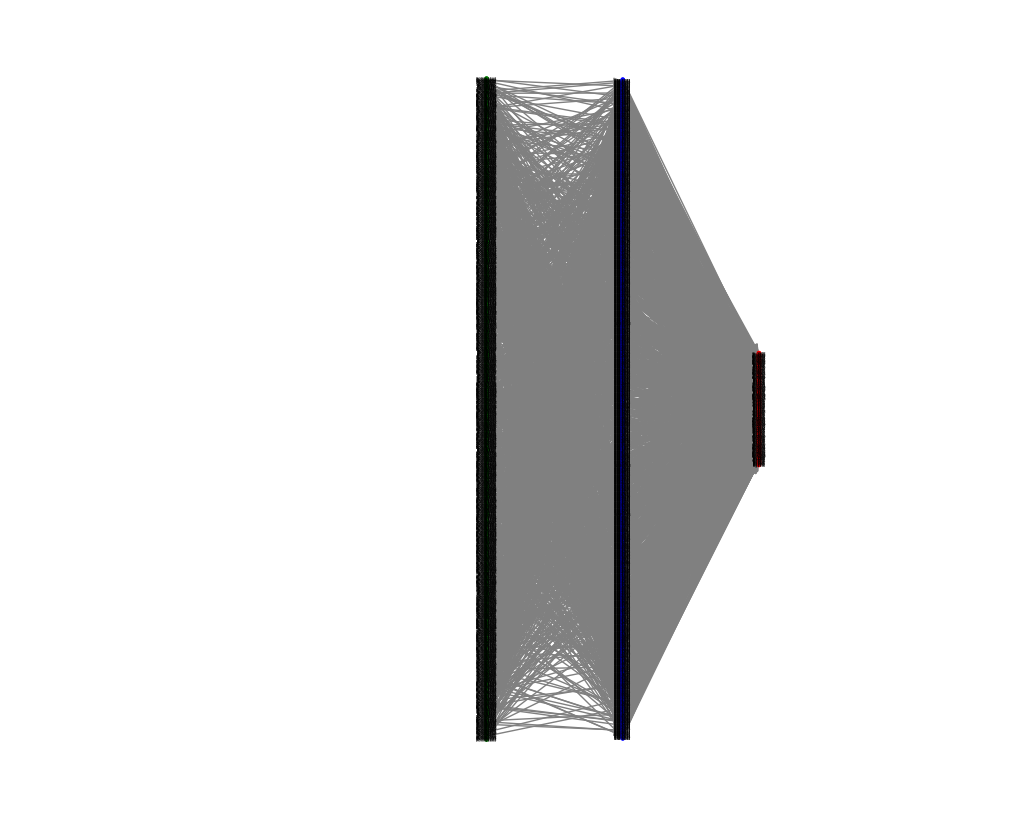

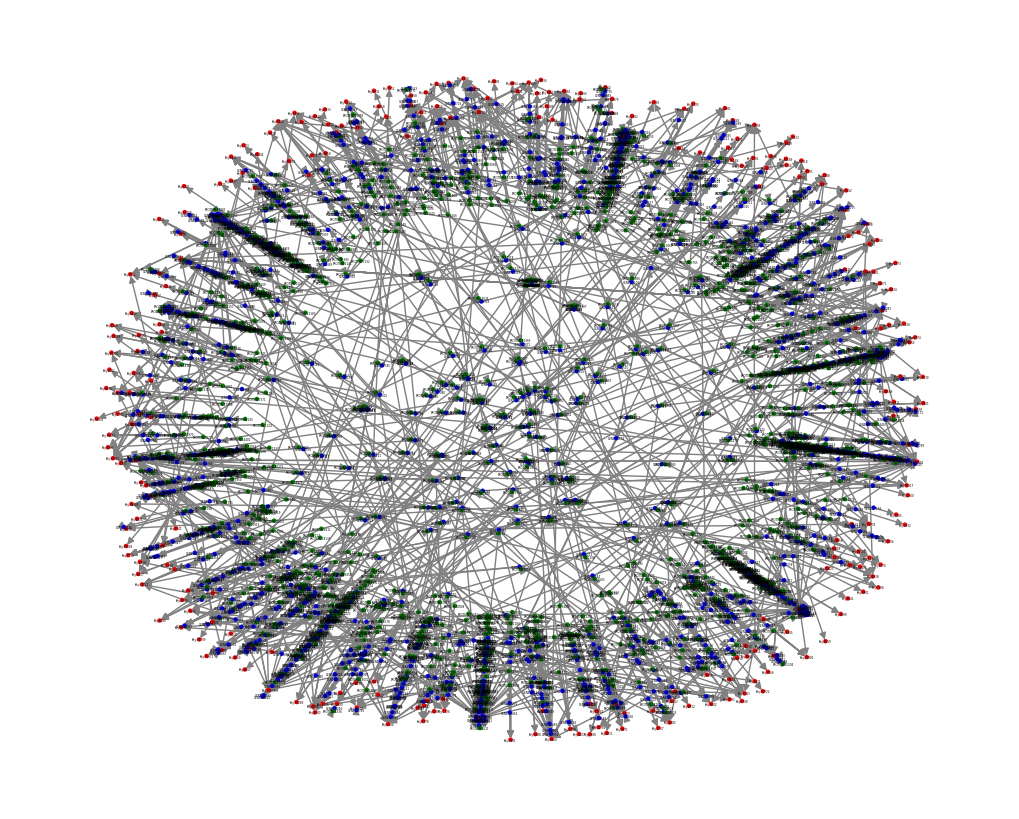

In [ ]:
plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=True, labels=labels, node_color=colors, edge_color='gray', node_size=5, font_size=2)
plt.savefig('kg-layered.pdf')
plt.show()
plt.figure(figsize=(10, 8))
nx.draw(G, with_labels=True, labels=labels, node_color=colors, edge_color='gray', node_size=5, font_size=2)
plt.savefig('kg.pdf')
plt.show()

In [ ]:

plt.figure(figsize=(10, 8))
nx.draw(G, with_labels=True, labels=labels, node_color=colors, edge_color='gray', node_size=5, font_size=2)
plt.savefig('kg.pdf')
plt.show()

In [9]:
from functools import reduce
from statistics import mean
from operator import mul

class TruthValue:
    Not = lambda x: (1-x)

    And = lambda *x: reduce(mul, x, 1)
    Or  = lambda *x: 1 - reduce(mul, (1 - xi for xi in x), 1)
    Average = lambda *x: mean(x)

    fc_to_w_plus    = lambda f, c, k: k*f*c/(1-c)
    fc_to_w         = lambda f, c, k: k*c/(1-c)
    fc_to_w_minus   = lambda f, c, k: k*(1-f)*c/(1-c)

    w_to_f          = lambda w_plus, w: w_plus/max(w, 1e-4)
    w_to_c          = lambda w, k     : w/(w+k)

    F_ded = lambda f1, c1, f2, c2: (TruthValue.And(f1, f2), TruthValue.And(f1, f2, c1, c2))  # return: f, c


    def __init__(self, f, c, k=1):
        self.f = f
        self.c = c
        self.k = k
    
    def revision(self, truthvalue: 'TruthValue'):
        w1p = TruthValue.fc_to_w_plus(self.f, self.c, self.k)
        w2p = TruthValue.fc_to_w_plus(truthvalue.f, truthvalue.c, truthvalue.k)
        w1  = TruthValue.fc_to_w(self.f, self.c, self.k)
        w2  = TruthValue.fc_to_w(truthvalue.f, truthvalue.c, truthvalue.k)
        f = TruthValue.w_to_f(w1p + w2p, w1 + w2)
        c = TruthValue.w_to_c(w1 + w2, self.k)
        self.f = f
        self.c = c
        return self
    
    @property
    def w(self):
        return TruthValue.fc_to_w(self.f, self.c, self.k)
    
    @property
    def e(self):
        return (self.c * (self.f - 0.5) + 0.5)

    @staticmethod
    def deduction(truthvalue1: 'TruthValue', truthvalue2: 'TruthValue'):
        f, c = TruthValue.F_ded(truthvalue1.f, truthvalue2.f, truthvalue1.c, truthvalue2.c)
        return TruthValue(f, c, truthvalue1.k)
        
    
    def __repr__(self):
        return f"<TruthValue: %{self.f:.2f};{self.c:.2f}% (k={self.k}))"

In [10]:
def deductive_reasoning(G, proteins: list[tuple[str, TruthValue]]) -> list[tuple[str, TruthValue]]:
    """
    Perform deductive reasoning on the knowledge graph.
    
    Args:
        G (networkx.DiGraph): The knowledge graph.
        proteins (list): List of proteins to reason about."

    Returns:
        list: List of diseases associated with the given proteins.
    """
    for node in G.nodes:
        G.nodes[node]['truth'] = TruthValue(0.0, 0.0, 1)

    
    for protein, truth_value in proteins:
        if not G.has_node(protein):
            continue
        G.nodes[protein]['truth'] = truth_value

    # propagate from layer 1 to layer 2
    for node in G.nodes:
        if G.nodes[node]['layer'] == 1:
            truth1: TruthValue = G.nodes[node]['truth']
            for neighbor in G.neighbors(node):
                if G.nodes[neighbor]['layer'] == 2:
                    truth2: TruthValue = G.nodes[neighbor]['truth']
                    # Update the truth value of the neighbor
                    TruthValue.deduction(TruthValue(1.0, 0.9), truth1)
                    truth2.revision(truth1)
    # propagate from layer 2 to layer 3
    for node in G.nodes:
        if G.nodes[node]['layer'] == 2:
            truth1: TruthValue = G.nodes[node]['truth']
            for neighbor in G.neighbors(node):
                if G.nodes[neighbor]['layer'] == 3:
                    truth2: TruthValue = G.nodes[neighbor]['truth']
                    # Update the truth value of the neighbor
                    TruthValue.deduction(TruthValue(1.0, 0.9), truth1)
                    truth2.revision(truth1)
    # collect the results in layer3
    results = []
    for node in G.nodes:
        if G.nodes[node]['layer'] == 3:
            truth: TruthValue = G.nodes[node]['truth']
            results.append((node, truth))
    results = [(node, truth) for node, truth in results if truth.w > 1e-3]
    
    return results
    
            
    
    

In [11]:
proteins_all = []
for v in kg.values():
    for _, proteins in v:
        proteins_all.extend(proteins)
proteins_all = list(set(proteins_all))

In [12]:
len(proteins_all)

1517

In [13]:
import random
proteins = random.sample(proteins_all, 10)
proteins = [(protein, TruthValue(random.random(), 0.9)) for protein in proteins]

In [14]:
proteins

[('PROTEIN:1097', <TruthValue: %0.11;0.90% (k=1))),
 ('PROTEIN:13975', <TruthValue: %0.19;0.90% (k=1))),
 ('PROTEIN:20064', <TruthValue: %0.24;0.90% (k=1))),
 ('PROTEIN:717', <TruthValue: %0.64;0.90% (k=1))),
 ('PROTEIN:10127', <TruthValue: %0.33;0.90% (k=1))),
 ('PROTEIN:15368', <TruthValue: %0.24;0.90% (k=1))),
 ('PROTEIN:783', <TruthValue: %0.46;0.90% (k=1))),
 ('PROTEIN:1382', <TruthValue: %0.27;0.90% (k=1))),
 ('PROTEIN:17796', <TruthValue: %0.32;0.90% (k=1))),
 ('PROTEIN:15886', <TruthValue: %0.09;0.90% (k=1)))]

In [15]:
from icd9_to_text import get_description

In [16]:
results = deductive_reasoning(G, proteins)
results = [(get_description(code), truth) for code, truth in sorted(results, key=lambda x: x[1].e, reverse=True)]

In [17]:
results

[('Cardiac dysrhythmias NEC', <TruthValue: %0.64;0.90% (k=1))),
 ('Prim cardiomyopathy NEC', <TruthValue: %0.64;0.90% (k=1))),
 ('Genetic torsion dystonia', <TruthValue: %0.46;0.90% (k=1))),
 ('Lipidoses', <TruthValue: %0.32;0.90% (k=1))),
 ('Skin anomaly NEC', <TruthValue: %0.27;0.90% (k=1))),
 ('Myopathies NEC', <TruthValue: %0.26;0.95% (k=1))),
 ('Autosomal deletions NEC', <TruthValue: %0.24;0.90% (k=1))),
 ('Prader-willi syndrome', <TruthValue: %0.24;0.90% (k=1))),
 ('Anomal skull/face bones', <TruthValue: %0.24;0.90% (k=1))),
 ('Hered sensory neuropathy', <TruthValue: %0.19;0.90% (k=1))),
 ('Renovasc hypertension', <TruthValue: %0.11;0.90% (k=1))),
 ('Hered spastic paraplegia', <TruthValue: %0.09;0.90% (k=1)))]